# Classificazione di fiori con una CNN in PyTorch

In questo notebook costruiamo una **Convolutional Neural Network (CNN)** per classificare immagini di fiori in 5 categorie:
- 🌼 daisy
- 🌻 sunflower
- 🌹 roses
- 🌷 tulips
- 🌸 dandelion

Il dataset è organizzato in sottocartelle, una per classe — il formato standard per `ImageFolder` di torchvision.

## Struttura del notebook
1. Import e configurazione device
2. Caricamento e preprocessing del dataset
3. Definizione del modello CNN
4. Training loop
5. Valutazione sul test set
6. Visualizzazione dei risultati

## 1. Import e configurazione del device

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import time

# PyTorch usa automaticamente GPU (CUDA) se disponibile, altrimenti CPU
# Su Mac M-series si può usare 'mps' per accelerazione Apple Silicon
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Device in uso: {device}')

Device in uso: mps


## 2. Caricamento e preprocessing del dataset

### Trasformazioni

Prima di dare le immagini alla rete, applichiamo alcune trasformazioni:

- **Resize(224, 224)**: ridimensioniamo tutte le immagini a 224×224 pixel. Le immagini originali hanno dimensioni diverse, la rete richiede input di dimensione fissa.
- **RandomHorizontalFlip**: data augmentation — capovolge casualmente l'immagine orizzontalmente durante il training per rendere il modello più robusto.
- **RandomRotation**: rotazione casuale di ±15 gradi, altra tecnica di augmentation.
- **ToTensor()**: converte l'immagine da PIL (valori 0-255) a tensore PyTorch (valori 0.0-1.0).
- **Normalize**: standardizza i valori usando media e deviazione standard precalcolate su ImageNet. Si usa questa convenzione perché è lo standard per i modelli pre-addestrati.

In [2]:
# Trasformazioni per il training (con data augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),          # Ridimensiona a 224x224
    transforms.RandomHorizontalFlip(),      # Flip orizzontale casuale (augmentation)
    transforms.RandomRotation(15),          # Rotazione casuale ±15° (augmentation)
    transforms.ToTensor(),                  # Converte in tensore [0,1]
    transforms.Normalize(                   # Normalizza con valori ImageNet
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Trasformazioni per il test (senza augmentation — solo preprocessing)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [3]:
# ⚠️ Modifica questo path con il percorso corretto sul tuo Mac
DATA_DIR = "flower_photos"

# ImageFolder carica automaticamente le immagini dalle sottocartelle
# La struttura attesa è:
#   flower_photos/
#     daisy/
#     dandelion/
#     roses/
#     sunflowers/
#     tulips/

# Carichiamo prima tutto il dataset con le trasformazioni di training
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transforms)

# Le classi vengono rilevate automaticamente dai nomi delle sottocartelle
class_names = full_dataset.classes
num_classes = len(class_names)
print(f'Classi rilevate: {class_names}')
print(f'Numero di classi: {num_classes}')
print(f'Totale immagini: {len(full_dataset)}')

Classi rilevate: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Numero di classi: 5
Totale immagini: 3670


In [4]:
# Divisione in training set (80%) e test set (20%)
# random_split divide casualmente il dataset nelle proporzioni indicate
total = len(full_dataset)
train_size = int(0.8 * total)
test_size = total - train_size

train_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)  # per riproducibilità
)

print(f'Training set: {len(train_dataset)} immagini')
print(f'Test set:     {len(test_dataset)} immagini')

# DataLoader: gestisce il caricamento in batch e lo shuffle
# batch_size=32: la rete vede 32 immagini alla volta prima di aggiornare i pesi
# shuffle=True: mescola i dati ad ogni epoca (importante per il training)
# num_workers=2: usa 2 processi paralleli per caricare i dati più velocemente
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f'\nBatch di training: {len(train_loader)}')
print(f'Batch di test:     {len(test_loader)}')

Training set: 2936 immagini
Test set:     734 immagini

Batch di training: 92
Batch di test:     23


### Visualizzazione di alcune immagini del dataset

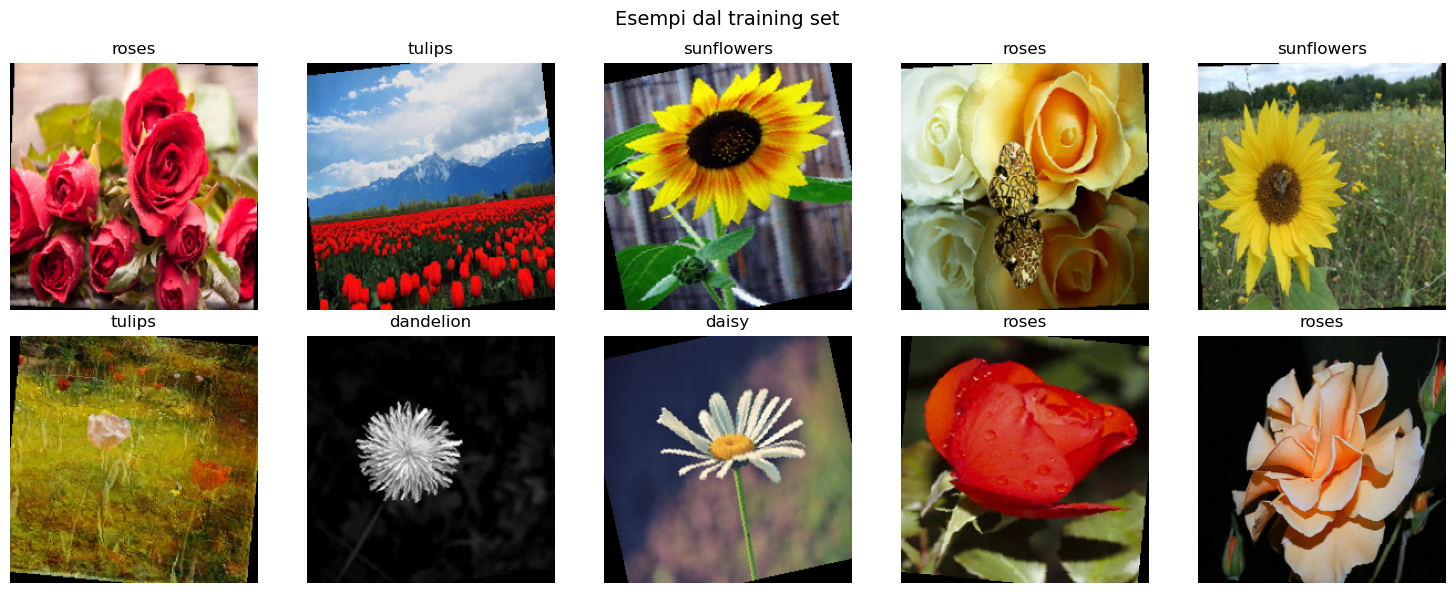

Shape di un batch di immagini: torch.Size([32, 3, 224, 224])
  → [batch_size, canali, altezza, larghezza] = [32, 3, 224, 224]


In [5]:
def denormalize(tensor):
    """Inverte la normalizzazione per visualizzare le immagini correttamente."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return torch.clamp(tensor * std + mean, 0, 1)

# Prendiamo un batch dal training loader
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(class_names[labels[i]])
    ax.axis('off')
plt.suptitle('Esempi dal training set', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Shape di un batch di immagini: {images.shape}')
print(f'  → [batch_size, canali, altezza, larghezza] = {list(images.shape)}')

## 3. Definizione del modello CNN

La rete è divisa in due blocchi:

### Blocco 1 — Feature Detector (`FeatDetector`)
Estrae le caratteristiche visive dall'immagine tramite layer convoluzionali.

| Layer | Input | Output | Dimensione spaziale |
|-------|-------|--------|--------------------|
| Conv2d(3→32, 5×5, pad=1) | 3×224×224 | 32×221×221 | (224 - 5 + 2×1 + 1) = 221 |
| BatchNorm2d + ReLU | — | — | invariata |
| MaxPool2d(2) | 32×221×221 | 32×110×110 | 221 // 2 = 110 |
| Conv2d(32→64, 5×5, pad=1) | 32×110×110 | 64×107×107 | (110 - 5 + 2×1 + 1) = 107 |
| BatchNorm2d + ReLU | — | — | invariata |
| MaxPool2d(2) | 64×107×107 | 64×53×53 | 107 // 2 = 53 |

**Nota**: con input 224×224, l'output del FeatDetector ha dimensione **64×53×53**, quindi il Flatten produce **64×53×53 = 179.776** valori.

### Blocco 2 — Classifier
Classifica le feature estratte tramite layer fully connected.

- **Flatten**: appiattisce il tensore 3D in un vettore 1D
- **Dropout(0.3)**: durante il training, spegne casualmente il 30% dei neuroni per prevenire overfitting
- **Linear(179776 → 128)**: primo layer fully connected
- **ReLU**: attivazione non lineare
- **Linear(128 → 5)**: output finale, un valore per classe

### BatchNorm e ReLU

- **BatchNorm2d**: normalizza l'output del layer convoluzionale all'interno del batch, stabilizzando il training e permettendo learning rate più alti.
- **ReLU**: funzione di attivazione che introduce non linearità. Sostituisce i valori negativi con 0: `f(x) = max(0, x)`. Senza attivazioni non lineari, tutta la rete sarebbe equivalente a un singolo layer lineare.

In [14]:
class FlowerCNN(nn.Module):

    def __init__(self, num_classes=5):
        super(FlowerCNN, self).__init__()

        # Blocco convoluzionale: estrae feature visive dall'immagine
        self.FeatDetector = nn.Sequential(

            # --- Primo blocco conv ---
            # Input:  [batch, 3, 224, 224]  (3 canali RGB)
            # Output: [batch, 16, 224, 224] (16 filtri)
            nn.Conv2d(3, 16, kernel_size=5, padding=2),
            nn.BatchNorm2d(16),      # Normalizza i 32 canali in output
            nn.ReLU(inplace=True),   # Attivazione non lineare
            # Output dopo pool: [batch, 32, 110, 110] (221 // 2 = 110)
            nn.MaxPool2d(kernel_size=2),

            # --- Secondo blocco conv ---
            # Input:  [batch, 16, 112, 112]
            # Output: [batch, 32, 112, 112] (32 filtri)
            nn.Conv2d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            # Output dopo pool: [batch, 64, 56, 56]
            nn.MaxPool2d(kernel_size=2),

            # --- Secondo blocco conv ---
            # Input:  [batch, 32, 56, 56]
            # Output: [batch, 64, 56, 56] (64 filtri)
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            # Output dopo pool: [batch, 64, 28, 28]
            nn.MaxPool2d(kernel_size=2)
        )

        # Blocco classificatore: mappa le feature alle classi
        self.Classifier = nn.Sequential(
            nn.Flatten(),              # [batch, 64, 28, 28] → [batch, 50'176]
            nn.Dropout(0.3),           # Spegne il 30% dei neuroni (solo durante training)
            nn.Linear(64*28*28, 128),  # 179776 → 128  ✓ dimensione corretta
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)  # 128 → 5 classi
        )

    def forward(self, x):
        x = self.FeatDetector(x)  # Estrazione feature
        x = self.Classifier(x)    # Classificazione
        return x  # Output grezzo (logits) — la loss CrossEntropyLoss applica softmax internamente

In [15]:
# Istanziamo il modello e lo spostiamo sul device
model = FlowerCNN(num_classes=5).to(device)

# Verifichiamo l'architettura e il numero di parametri
print(model)
print()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parametri totali:      {total_params:,}')
print(f'Parametri addestrabili: {trainable_params:,}')

FlowerCNN(
  (FeatDetector): Sequential(
    (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (Classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3,

In [16]:
# Verifica rapida delle dimensioni con un forward pass su dati finti
dummy_input = torch.randn(4, 3, 224, 224).to(device)  # batch di 4 immagini RGB 224x224
dummy_output = model(dummy_input)
print(f'Input shape:  {list(dummy_input.shape)}')
print(f'Output shape: {list(dummy_output.shape)}')
print(f'  → [batch_size, num_classes] = [4, 5] ✓')

Input shape:  [4, 3, 224, 224]
Output shape: [4, 5]
  → [batch_size, num_classes] = [4, 5] ✓


## 4. Loss function e ottimizzatore

- **CrossEntropyLoss**: la loss standard per classificazione multi-classe. Internamente applica il softmax all'output della rete e calcola la negative log-likelihood. Per questo il modello restituisce logits grezzi (non softmax).
- **Adam**: ottimizzatore che adatta il learning rate per ogni parametro. È il più usato in pratica come punto di partenza.
- **lr=1e-3**: learning rate — controlla quanto i pesi vengono aggiornati ad ogni step.
- **StepLR**: scheduler che riduce il learning rate di un fattore `gamma` ogni `step_size` epoche. Aiuta la convergenza nelle fasi finali del training.

In [17]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Riduce il lr del 50% ogni 5 epoche
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

## 5. Training loop

Ad ogni **epoca** il modello vede tutto il training set una volta. Per ogni **batch**:

1. **Forward pass**: le immagini passano attraverso la rete e produciamo le predizioni
2. **Loss**: calcoliamo quanto le predizioni si discostano dalle etichette reali
3. **Backward pass**: calcoliamo il gradiente della loss rispetto a tutti i parametri (backpropagation)
4. **Optimizer step**: aggiorniamo i pesi nella direzione che riduce la loss

In [18]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Addestra il modello per una singola epoca."""
    model.train()  # Modalità training: attiva Dropout e BatchNorm in modalità training
    
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # Azzera i gradienti del passo precedente
        outputs = model(images)        # Forward pass
        loss = criterion(outputs, labels)  # Calcola la loss
        loss.backward()                # Backward pass (calcola i gradienti)
        optimizer.step()               # Aggiorna i pesi

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)  # Classe con il punteggio più alto
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    """Valuta il modello sul loader fornito (validation o test)."""
    model.eval()  # Modalità evaluation: disattiva Dropout, usa statistiche fisse per BatchNorm
    
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # Disabilita il calcolo dei gradienti (risparmia memoria)
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc

In [ ]:
NUM_EPOCHS = 15

history = {
    'train_loss': [], 'train_acc': [],
    'test_loss':  [], 'test_acc':  []
}

print(f"{'Epoca':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Loss':>9} | {'Test Acc':>8} | {'LR':>8}")
print('-' * 65)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss,  test_acc  = evaluate(model, test_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f'{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.2%} | {test_loss:>9.4f} | {test_acc:>7.2%} | {current_lr:>8.2e}')

elapsed = time.time() - start_time
print(f'\nTraining completato in {elapsed/60:.1f} minuti')

 Epoca | Train Loss | Train Acc | Test Loss | Test Acc |       LR
-----------------------------------------------------------------
     1 |     2.4650 |   41.62% |    1.0812 |  55.31% | 1.00e-03
     2 |     1.1631 |   53.07% |    1.2054 |  48.23% | 1.00e-03
     3 |     1.0965 |   56.44% |    0.9719 |  62.53% | 1.00e-03
     4 |     1.0380 |   59.67% |    1.0011 |  60.22% | 1.00e-03
     5 |     1.0084 |   61.00% |    1.0353 |  57.63% | 5.00e-04
     6 |     0.9126 |   65.02% |    0.8963 |  66.35% | 5.00e-04


## 6. Visualizzazione dei risultati

In [ ]:
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs, history['train_loss'], label='Training', marker='o')
ax1.plot(epochs, history['test_loss'],  label='Test',     marker='o')
ax1.set_title('Loss per epoca')
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs, history['train_acc'], label='Training', marker='o')
ax2.plot(epochs, history['test_acc'],  label='Test',     marker='o')
ax2.set_title('Accuracy per epoca')
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Accuracy')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nAccuracy finale sul test set: {history["test_acc"][-1]:.2%}')

In [ ]:
# Visualizzazione delle predizioni sul test set
model.eval()
images, labels = next(iter(test_loader))
images_device = images.to(device)

with torch.no_grad():
    outputs = model(images_device)
    _, predicted = outputs.max(1)

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    
    true_label = class_names[labels[i]]
    pred_label = class_names[predicted[i].cpu()]
    correct    = true_label == pred_label
    
    color = 'green' if correct else 'red'
    ax.set_title(f'Vero: {true_label}\nPred: {pred_label}', color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('Predizioni sul test set (verde=corretto, rosso=errato)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Matrice di confusione
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Matrice di confusione — Test set')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Riepilogo

In questo notebook abbiamo:

- Caricato il dataset flower_photos con `ImageFolder` di torchvision
- Applicato **data augmentation** (flip, rotazione) durante il training per ridurre l'overfitting
- Costruito una **CNN** con due blocchi convoluzionali (Conv → BatchNorm → ReLU → MaxPool) e un classificatore fully connected
- Addestrato il modello con **CrossEntropyLoss** e ottimizzatore **Adam**
- Usato uno **scheduler** per ridurre il learning rate durante il training
- Visualizzato loss, accuracy, predizioni e **matrice di confusione**

### Correzione rispetto al codice del professore

Il codice originale aveva `nn.Linear(64*53*53, 128)` come dimensione del layer fully connected. Con input 224×224 la dimensione corretta è appunto **64×53×53 = 179.776** — come verificato calcolando il forward pass passo per passo.